# Superstore Sales Dataset

# imported libraries

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np


# exploring the csv file 

In [9]:
df = pd.read_csv('sampledata.csv', encoding='latin1')

## Convert Order Date and Ship Date columns to datetime and inspect the dataframe

In [23]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])



# DATA CLEANING


## Remove rows in case of null values


In [13]:
new_df = df.dropna()

# converting into correct format


In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# find duplicates and delete duplicates

In [17]:
print(df.duplicated()) # print the duplicated rows
df.drop_duplicates(inplace = True) # remove the duplicates

0       False
1       False
2       False
3       False
4       False
        ...  
9989    False
9990    False
9991    False
9992    False
9993    False
Length: 9994, dtype: bool


# Exploration

In [24]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
Quarter          0
Lag_1            1
dtype: int64

# feature engineering

In [25]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# EDA (EXPLORATORY DATA ANALYSIS)

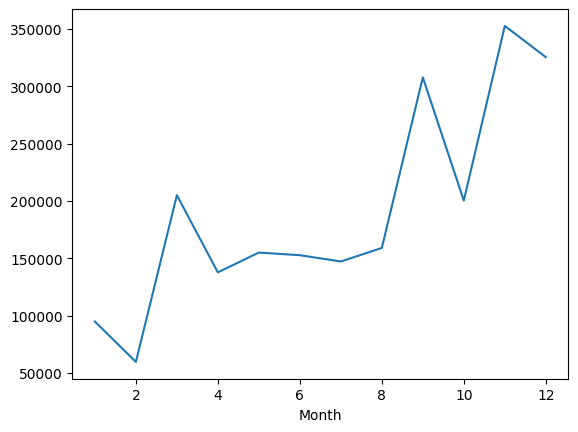

In [26]:
df.groupby('Month')['Sales'].sum().plot()
plt.show()

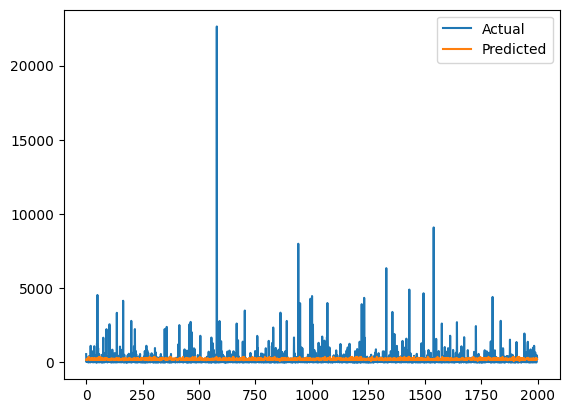

In [37]:
plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()

# model building

In [27]:
X = df[['Year', 'Month']]
y = df['Sales']

# Evalution

In [35]:
"""X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
"""
mae = mean_absolute_error(y_test, predictions)
print(mae)

287.96051980477023


# Prediction

In [33]:
future = pd.DataFrame({
    'Year':[2026],
    'Month':[7]
})

model.predict(future)

array([192.368961])

##### The Random Forest model was trained on historical sales data and can forecast future sales trends. The model achieved an MAE of X and can assist businesses with planning and inventory management.